In [10]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import seaborn as sns
import random
from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report

In [91]:
np.random.seed(45)
def generate_points(size=(1000,2)):
    return np.random.random(size)

def get_train_test(num_points=1000, dimension=2, f=None, same_test_pts=False):
    f_label = f if f!=None else lambda pt: int(pt[1] > 1-pt[0])
    X_train = generate_points(size=(num_points,dimension))
    y_train = [f_label(point) for point in X_train]
    X_test = generate_points(size=(num_points,dimension)) if not same_test_pts else generate_points(size=(200,dimension))
    y_test = [f_label(point) for point in X_test]
    return X_train, X_test, y_train, y_test

Comparing 1000 vectors with a dimension of 2


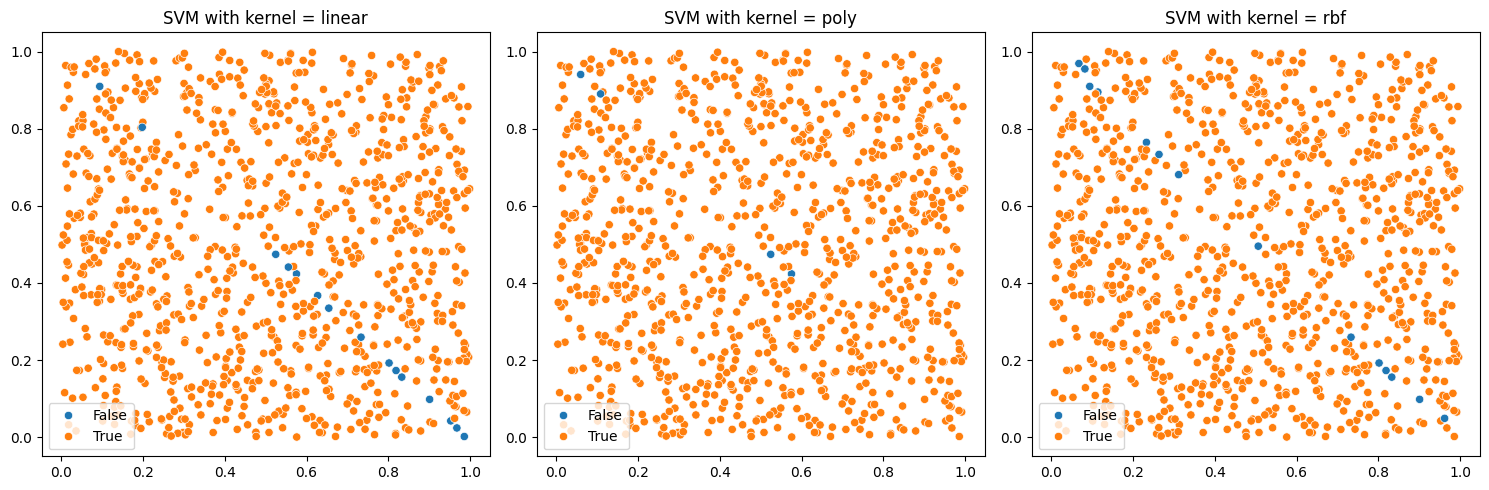

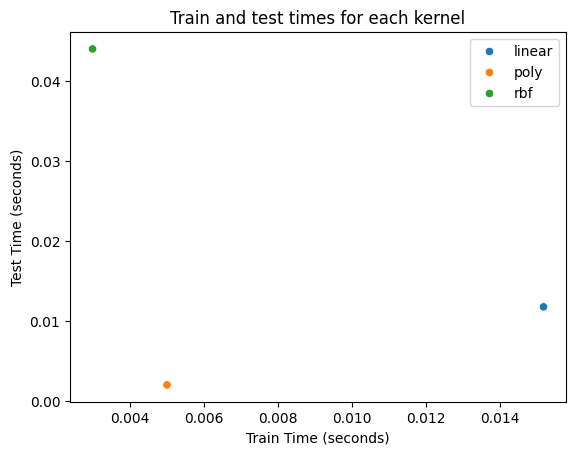

Best kernel is poly with a score of 0.996


In [93]:
from time import time

kernels = ["linear", "poly", "rbf"]



def compare_kernels(kernels, num_points=1000, dimension=2, plot_prediction=True, plot_times=True, f=None, degree=None, same_test_pts=False):
    print(f"Comparing {num_points} vectors with a dimension of {dimension}")
    X_train, X_test, y_train, y_test = get_train_test(num_points, dimension, f=f, same_test_pts=same_test_pts)
    times = []
    scores = np.zeros(len(kernels))
    clfs = []
    fig, axes = None, None
    if plot_prediction:
        fig, axes = plt.subplots(nrows=1, ncols=len(kernels), figsize=(15, 5))  # Adjust figsize as needed
    for i,kernel in enumerate(kernels):
        clf = svm.SVC(kernel=kernel)
        if degree != None and kernel=="poly":
            print("Poly of degree 2")
            clf = svm.SVC(kernel=kernel, degree=degree)
        train_start_time = time()
        clf.fit(X_train,y_train)
        train_time = time()-train_start_time

        test_start_time = time()
        y_pred = clf.predict(X_test)
        test_time = time() - test_start_time

        times.append((train_time, test_time))

        if plot_prediction:
            ax = sns.scatterplot(x=X_test[:,0], y=X_test[:,1], hue=y_pred==y_test, ax=axes[i] )
            if degree != None and kernel=="poly":
                ax.set_title(f"SVM with kernel = {kernel}, and degree={degree}")
            else:
                ax.set_title(f"SVM with kernel = {kernel}")


        score = clf.score(X_test, y_test)
        scores[i] = score
        clfs.append(clf)

    if plot_prediction:
        plt.tight_layout()
        plt.show()

    if plot_times:
        ax = sns.scatterplot(x=np.array(times)[:,0], y=np.array(times)[:,1], hue=kernels)
        ax.set_xlabel("Train Time (seconds)")
        ax.set_ylabel("Test Time (seconds)")
        ax.set_title("Train and test times for each kernel")
        # print(times)
        plt.show()

    best_clf_index = np.argmax(scores)
    best_kernel = kernels[best_clf_index]
    best_clf = clfs[best_clf_index]
    print(f"Best kernel is {best_kernel} with a score of {max(scores)}")
    return best_clf, times, scores

best_clf, times, acc_scores = compare_kernels(kernels, 1000, 2)


In [14]:
def print_svm(best_clf, num_points=1000, dimension=2):
    print("printing with", num_points, dimension)
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Create grid to evaluate model
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = best_clf.decision_function(xy).reshape(XX.shape)

    X_train, X_test, y_train, y_test = get_train_test(num_points, dimension)
    best_clf.fit(X_train, y_train)
    # Plot decision boundary and margins
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
            linestyles=['--', '-', '--'])
    # ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,
    #            linewidth=1, facecolors='none', edgecolors='k')
    # sns.scatterplot(x=X_train[:,0],y=X_train[:,1], hue=y_train)
    ax = sns.scatterplot(x=X_test[:,0],y=X_test[:,1], hue=y_test)
    ax.set_title("Test set and SVM fitted line")
    plt.show()


printing with 1000 2


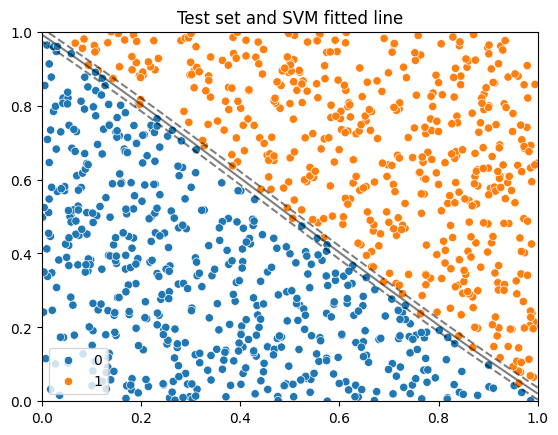

In [5]:
print_svm(best_clf)


In [6]:
num_points = 10000
vector_dim = 10
X_train, X_test = generate_points((vector_dim, num_points)), generate_points((vector_dim, num_points))
f_label = lambda pt: int(pt[1] > 1-pt[0])
y_train = [f_label(point) for point in X_train]
y_test =  [f_label(point) for point in X_test]

Comparing 10000 vectors with a dimension of 10


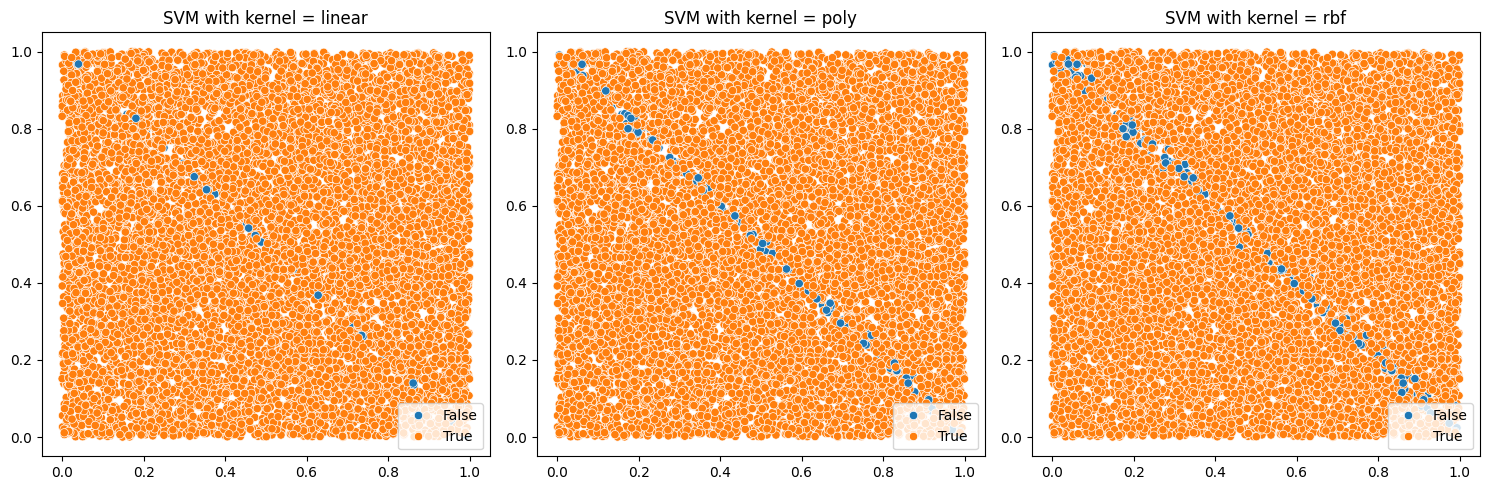

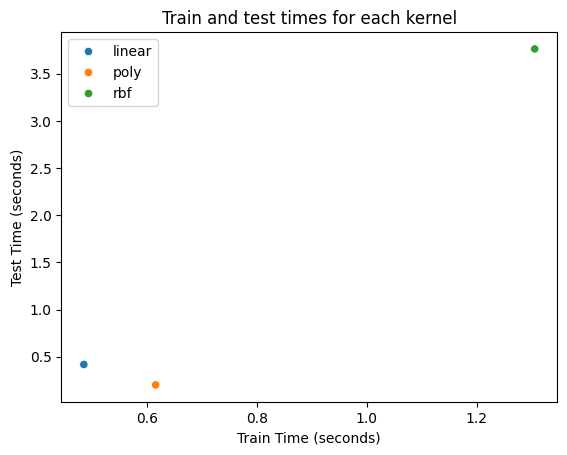

Best kernel is linear with a score of 0.996


In [7]:

best_clf = compare_kernels(kernels=kernels, num_points=num_points, dimension=vector_dim)

Comparing 10000 vectors with a dimension of 2


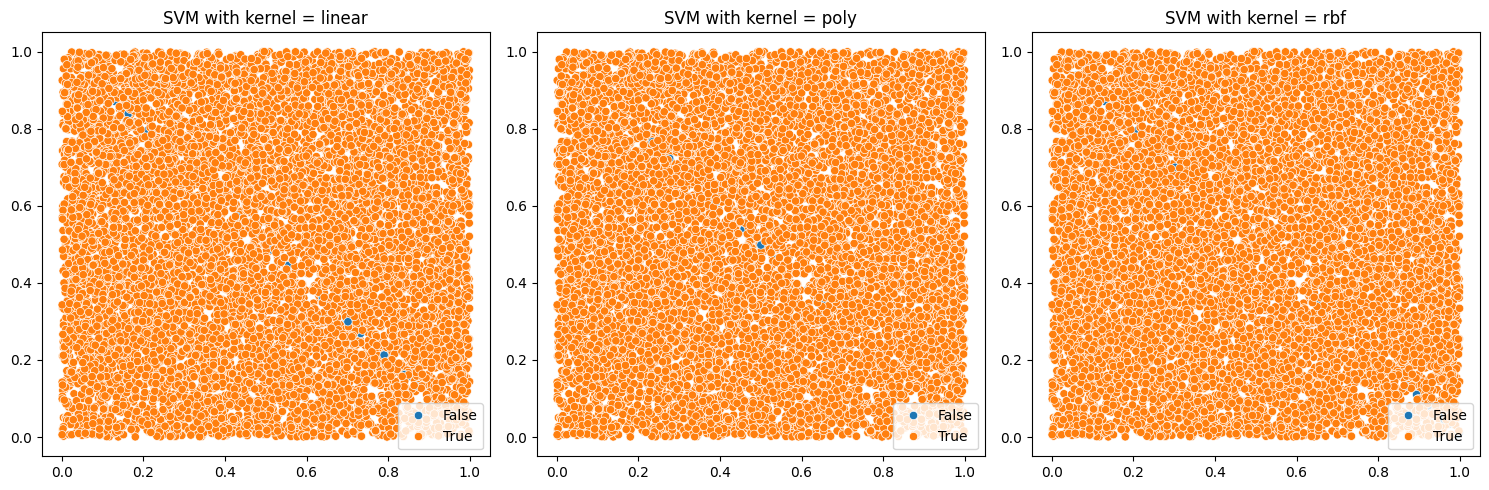

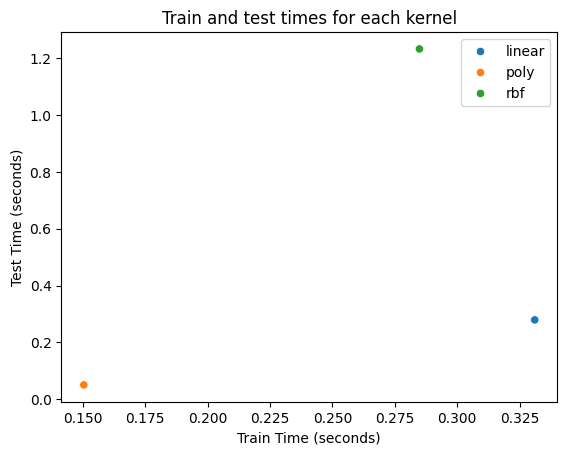

Best kernel is poly with a score of 0.9988


In [8]:
best_clf = compare_kernels(kernels=kernels, num_points=num_points, dimension=2)


Comparing different N=samples and P=dimension

In [9]:
number_samples = 1300
dimensions = [100,200,500,700,1000,1100, 1300, 1500,1750,2000]
dimensions_times = []
dimensions_acc = []
for dimension in dimensions:
    
    best_clf, times, acc_scores = compare_kernels(kernels=[best_clf.kernel], num_points=number_samples, dimension=dimension, plot_prediction=False, plot_times=False)
    dimensions_times.append(times[0])
    dimensions_acc.append(acc_scores[0])
    

AttributeError: 'tuple' object has no attribute 'kernel'

['P<<N', 'P<<N', 'P<<N', 'P<<N', 'P==N', 'P>>N', 'P>>N', 'P>>N', 'P>>N', 'P>>N']


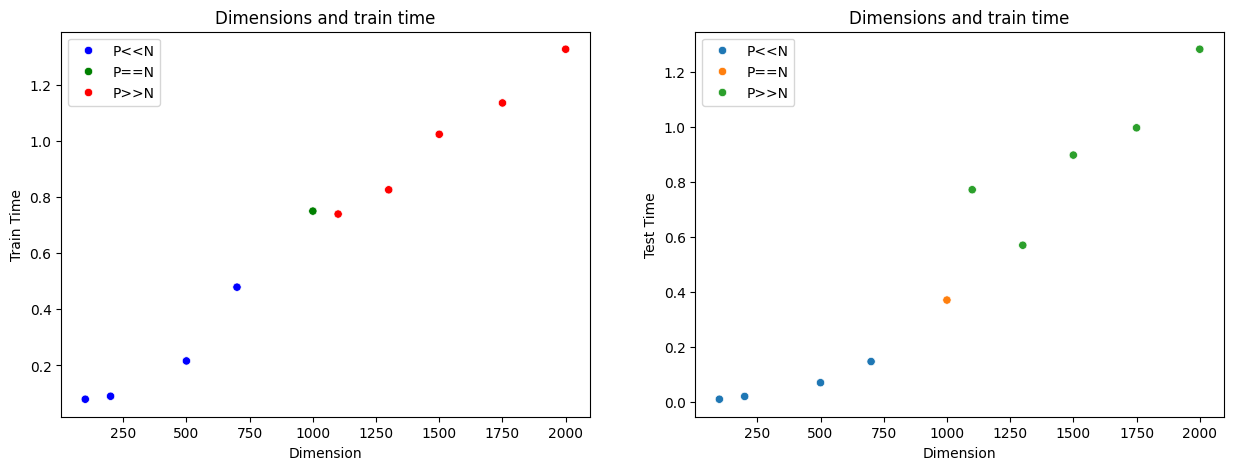

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
# ax = sns.scatterplot(x=dimensions, y=[e[0] for e in dimensions_times])
hue = ["P==N" if d == number_samples else "P>>N" if d > number_samples else "P<<N" for d in dimensions]
hue = [str(h) for h in hue]
print(hue)
# ax = sns.lineplot(x=dimensions, y=[e[0] for e in dimensions_times], hue=hue, palette=['blue', 'green', 'red'], legend="full")
ax = sns.scatterplot(x=dimensions, y=[e[0] for e in dimensions_times],hue=hue, palette=['blue', 'green', 'red'], legend="full", ax=axes[0])
ax.set_title("Dimensions and train time")
ax.set_xlabel("Dimension")
ax.set_ylabel("Train Time")

# ax = sns.scatterplot(x=dimensions, y=[e[1] for e in dimensions_times])
ax = sns.scatterplot(x=dimensions, y=[e[1] for e in dimensions_times], hue=hue, ax=axes[1])
ax.set_title("Dimensions and test time")
ax.set_xlabel("Dimension")
ax.set_ylabel("Test Time")

plt.show()

EX 3 - repeat 1 with different F - a circle

Comparing 1000 vectors with a dimension of 2


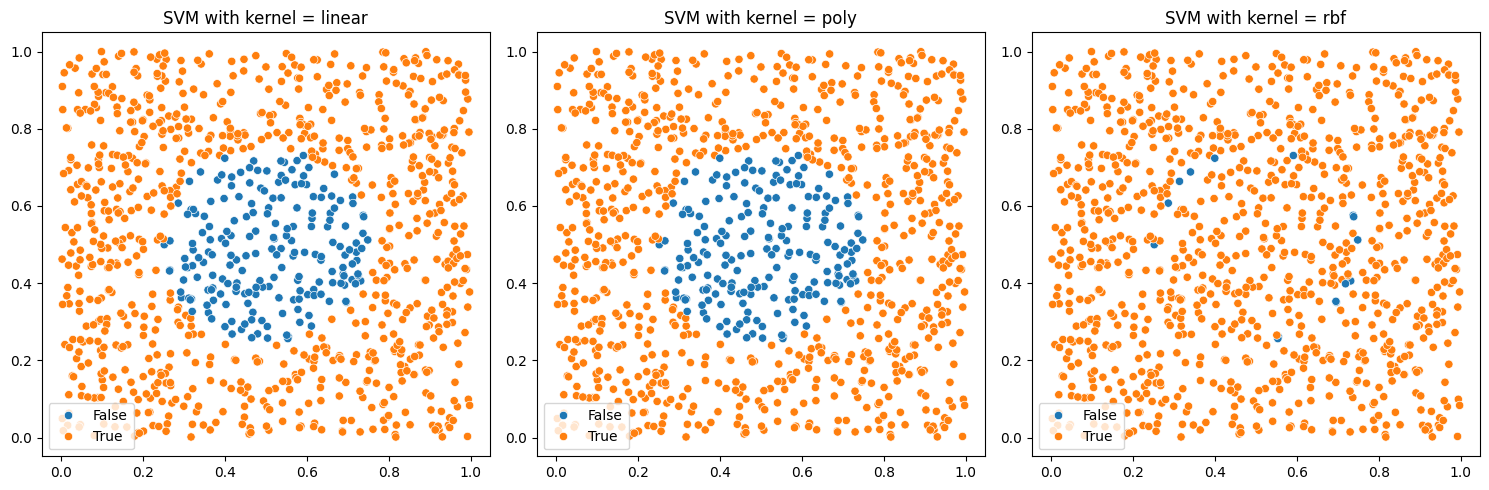

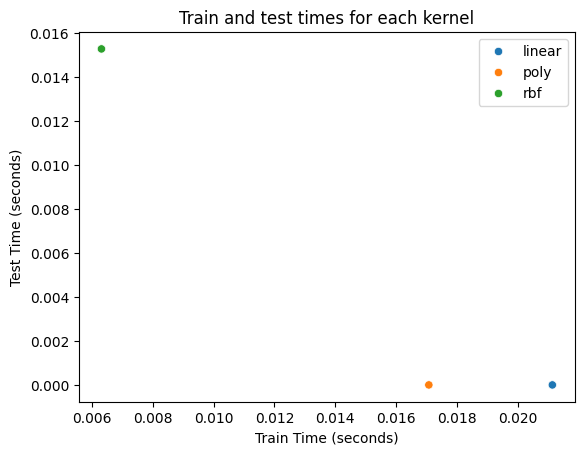

Best kernel is rbf with a score of 0.985


In [ ]:
# compare_kernels(["poly"])
# compare_kernels(["poly"], f=lambda pt: int(pt[1] > 1-pt[0]))
def is_point_in_circle(pt, center, radius):
    x, y = pt
    cx, cy = center
    distance_squared = (x - cx)**2 + (y - cy)**2
    radius_squared = radius**2
    return distance_squared <= radius_squared

best_clf, times, scores = compare_kernels(kernels=kernels, num_points=1000, dimension=2, f=lambda pt: is_point_in_circle(pt,(0.5,0.5),0.25))

Comparing 1000 vectors with a dimension of 2
Poly of degree 2


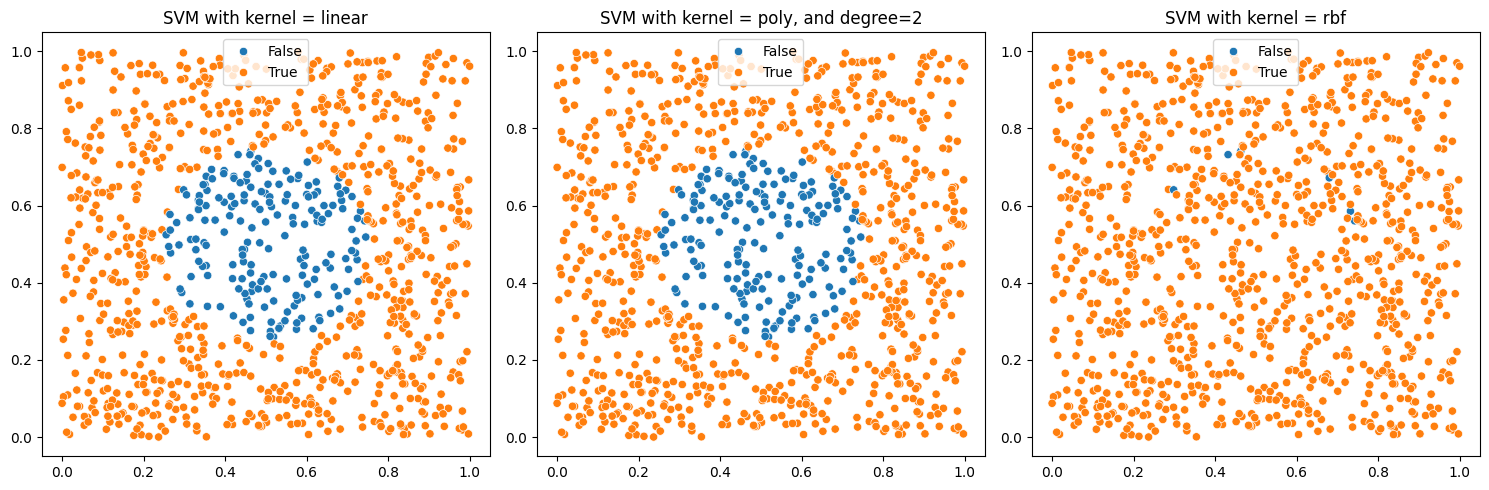

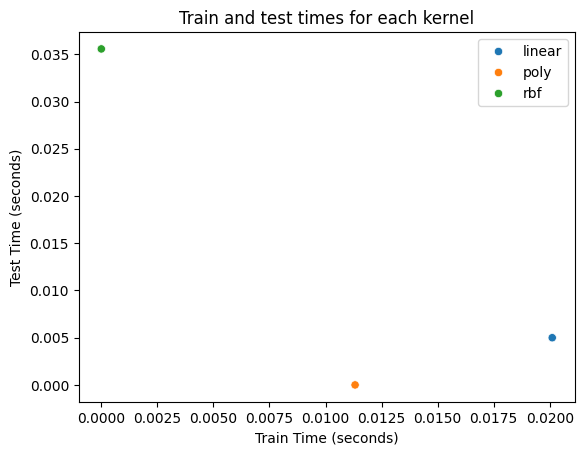

Best kernel is rbf with a score of 0.994


In [ ]:
# compare_kernels(["poly"])
# compare_kernels(["poly"], f=lambda pt: int(pt[1] > 1-pt[0]))
def is_point_in_circle(pt, center, radius):
    x, y = pt
    cx, cy = center
    distance_squared = (x - cx)**2 + (y - cy)**2
    radius_squared = radius**2
    return distance_squared <= radius_squared

best_clf, times, scores = compare_kernels(kernels=kernels, num_points=1000, dimension=2, f=lambda pt: is_point_in_circle(pt,(0.5,0.5),0.25), degree=2)


In [ ]:
print(scores) 
print("OMG SAME SCORES FOR LINEAR AND POLY WITH DEG = 2")

[0.801 0.801 0.985]
OMG SAME SCORES FOR LINEAR AND POLY WITH DEG = 2


# New part 2


In [97]:
number_samples_arr = [100,200,300, 350,400,500,600,700,800]
dimensions = [100,200,300,400,500,600,700,800]

# number_samples_arr = [150,250,350]
# dimensions = [100,200,300]
results = []
for number_samples in number_samples_arr:
    for dimension in dimensions:
        best_clf, times, acc_scores = compare_kernels(kernels=[best_clf.kernel], num_points=number_samples, dimension=dimension, plot_prediction=False, plot_times=False, same_test_pts=True)
        results.append([number_samples, dimension, acc_scores[0]])



Comparing 100 vectors with a dimension of 100
Best kernel is poly with a score of 0.725
Comparing 100 vectors with a dimension of 200
Best kernel is poly with a score of 0.725
Comparing 100 vectors with a dimension of 300
Best kernel is poly with a score of 0.635
Comparing 100 vectors with a dimension of 400
Best kernel is poly with a score of 0.625
Comparing 100 vectors with a dimension of 500
Best kernel is poly with a score of 0.615
Comparing 100 vectors with a dimension of 600
Best kernel is poly with a score of 0.615
Comparing 100 vectors with a dimension of 700
Best kernel is poly with a score of 0.625
Comparing 100 vectors with a dimension of 800
Best kernel is poly with a score of 0.59
Comparing 200 vectors with a dimension of 100
Best kernel is poly with a score of 0.74
Comparing 200 vectors with a dimension of 200
Best kernel is poly with a score of 0.72
Comparing 200 vectors with a dimension of 300
Best kernel is poly with a score of 0.72
Comparing 200 vectors with a dimensi

(72, 3)
x      100.0  200.0  300.0  350.0  400.0  500.0  600.0  700.0  800.0
y                                                                   
800.0  0.590  0.590  0.610  0.700  0.650  0.705  0.725  0.800  0.745
700.0  0.625  0.665  0.665  0.700  0.725  0.710  0.755  0.800  0.765
600.0  0.615  0.700  0.680  0.685  0.730  0.755  0.780  0.725  0.790
500.0  0.615  0.670  0.705  0.695  0.710  0.755  0.690  0.795  0.780
400.0  0.625  0.645  0.770  0.720  0.790  0.780  0.755  0.830  0.780
300.0  0.635  0.720  0.760  0.735  0.760  0.810  0.840  0.855  0.870
200.0  0.725  0.720  0.805  0.825  0.860  0.875  0.845  0.890  0.855
100.0  0.725  0.740  0.875  0.855  0.890  0.865  0.885  0.895  0.940


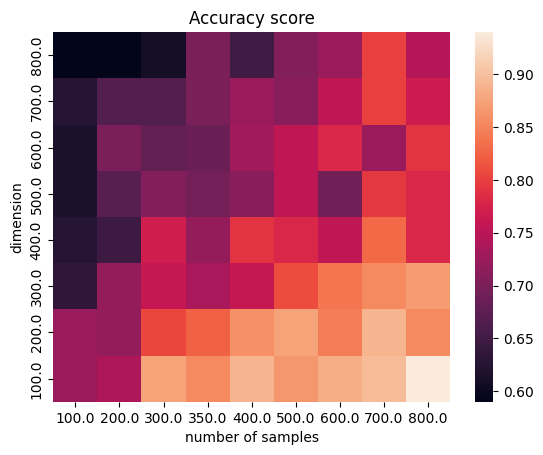

In [98]:
results1 = np.array(results)
# results1 = results1.squeeze()
print(results1.shape)

df = pd.DataFrame({'x': results1[:,0], 'y': results1[:,1], 'z': results1[:,2]})
# # Set x as index and pivot y as columns with z as values
df = df.pivot(index='y', columns='x', values='z')
df = df.sort_index(axis=0,ascending=False)
ax = sns.heatmap(data=df)
ax.set_xlabel("number of samples")
ax.set_ylabel("dimension")
ax.set_title("Accuracy score")
print(df)